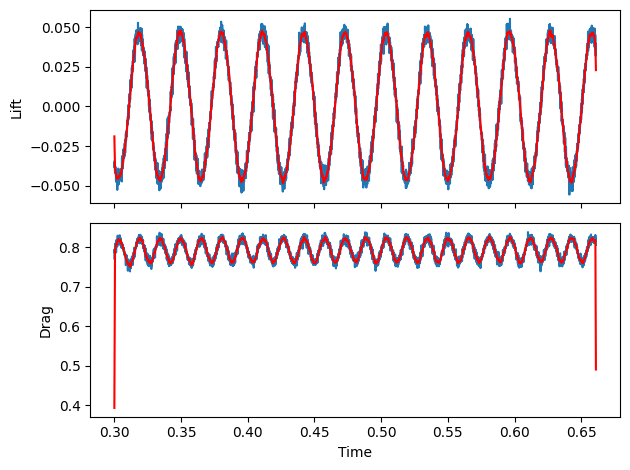

In [26]:
import numpy as np
import matplotlib.pyplot as plt

step, time, drag, lift = np.loadtxt("/Volumes/SherlockScratch/DSMC_FEM_VALIDATION_P1/BEAM_LOCKIN/PHASE_0/EXAMPLE/lift_drag.dat", skiprows=1, unpack=True)
st = 0.3
lift = lift[time > st]
drag = drag[time > st]
time = time[time > st]
# Quick fake cosine lift data for testing
# lift = 0.5 * np.cos(2 * np.pi * time / 10) + 0.5
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.plot(time, lift)
ax1.set_ylabel("Lift")

ax2.plot(time, drag)
ax2.set_ylabel("Drag")
ax2.set_xlabel("Time")

# set x limit to 0.15 to 0.25
# and align x axis of both subplots
# ax1.set_xlim(0.15, 0.3)
# ax2.set_xlim(0.15, 0.3)
# ax2.set_ylim(0.48,0.6)

# Plot windowed average
ax1.plot(time, np.convolve(lift, np.ones(10)/10, mode='same'), color='red', label='Windowed Average')
ax2.plot(time, np.convolve(drag, np.ones(10)/10, mode='same'), color='red', label='Windowed Average')
plt.tight_layout()
plt.show()

Detected Dominant Frequencies (Lift):
-> Frequency: 33.25 Hz | Amplitude: 72.92
-> Frequency: 96.98 Hz | Amplitude: 2.41
-> Frequency: 110.83 Hz | Amplitude: 1.27
-> Frequency: 127.46 Hz | Amplitude: 1.01


IndexError: invalid index to scalar variable.

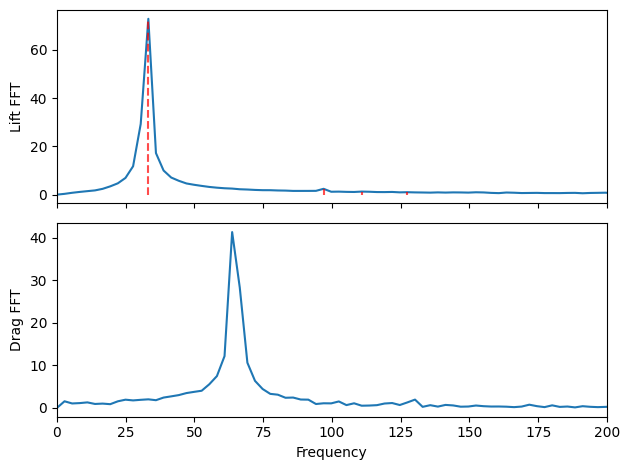

In [ ]:
dt = time[1] - time[0]
freq = np.fft.rfftfreq(len(time), d=dt)

lift_fft = np.abs(np.fft.rfft(lift-lift.mean()))
drag_fft = np.abs(np.fft.rfft(drag-drag.mean()))

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.plot(freq, lift_fft)
ax1.set_ylabel("Lift FFT")
ax1.set_xlim(0,200)
# ax1.set_yscale("log")

ax2.plot(freq, drag_fft)
ax2.set_ylabel("Drag FFT")
ax2.set_xlim(0,200)
ax2.set_xlabel("Frequency")
# ax2.set_yscale("log")

plt.tight_layout()
# plt.show()

from scipy.signal import find_peaks

# (Assuming positive_frequencies and positive_magnitudes are from the previous step)

# 1. Set a threshold to ignore noise (e.g., must be at least 5% of your max expected amplitude)
height_threshold = 1

# 2. Find the indices of the peaks
# 'distance' ensures you don't pick adjacent bins for the same broad peak
peak_indices, properties = find_peaks(lift_fft, height=height_threshold, distance=5)

# 3. Extract the actual frequency values and their amplitudes
dominant_frequencies = freq[peak_indices]
dominant_magnitudes = lift_fft[peak_indices]

# 4. Sort them from most dominant to least dominant
sort_order = np.argsort(dominant_magnitudes)[::-1]
sorted_frequencies = dominant_frequencies[sort_order]
sorted_magnitudes = dominant_magnitudes[sort_order]

# 5. Print the results
print("Detected Dominant Frequencies (Lift):")
for freq, amp in zip(sorted_frequencies, sorted_magnitudes):
    print(f"-> Frequency: {freq:.2f} Hz | Amplitude: {amp:.2f}")
    ax1.vlines(freq, 0, amp, color='red', linestyle='--', alpha=0.7, label=f'Detected Peak: {freq:.2f} Hz')

# 2. Find the indices of the peaks
# 'distance' ensures you don't pick adjacent bins for the same broad peak
peak_indices, properties = find_peaks(drag_fft, height=height_threshold, distance=5)

# 3. Extract the actual frequency values and their amplitudes
dominant_frequencies = np.fft.rfftfreq(len(time), d=dt)[peak_indices]
dominant_magnitudes = drag_fft[peak_indices]

# 4. Sort them from most dominant to least dominant
sort_order = np.argsort(dominant_magnitudes)[::-1]
sorted_frequencies = dominant_frequencies[sort_order]
sorted_magnitudes = dominant_magnitudes[sort_order]

# 5. Print the results
print("Detected Dominant Frequencies (Drag):")
for freq, amp in zip(sorted_frequencies, sorted_magnitudes):
    print(f"-> Frequency: {freq:.2f} Hz | Amplitude: {amp:.2f}")
    ax2.vlines(freq, 0, amp, color='red', linestyle='--', alpha=0.7, label=f'Detected Peak: {freq:.2f} Hz')

plt.show()

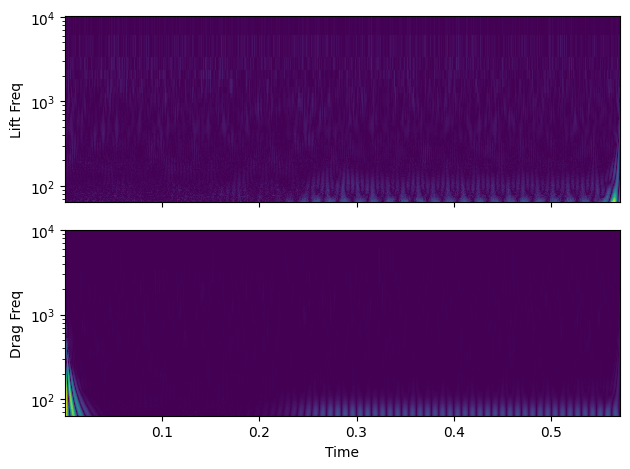

In [16]:
import pywt

scales = np.arange(1, 128)
lift_cwt, cwt_freqs = pywt.cwt(lift - lift.mean(), scales, "morl", sampling_period=dt)
drag_cwt, _ = pywt.cwt(drag - drag.mean(), scales, "morl", sampling_period=dt)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.pcolormesh(time, cwt_freqs, np.abs(lift_cwt), shading="auto")
ax1.set_ylabel("Lift Freq")

ax2.pcolormesh(time, cwt_freqs, np.abs(drag_cwt), shading="auto")
ax2.set_ylabel("Drag Freq")
ax2.set_xlabel("Time")
ax1.set_yscale("log")
ax2.set_yscale("log")

plt.tight_layout()
plt.show()